In [1]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT/MSFT.USUSD_Candlestick_1_D_ASK_05.10.2022-05.10.2024.csv")
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=20).mean()

df.reset_index(drop=True, inplace=True)

df

,Gmt time,Open,High,Low,Close,Volume,atr
0,2022-10-04 21:00:00,246.203,250.603,244.134,249.363,199.9032,NaN
1,2022-10-05 21:00:00,248.663,250.364,246.203,246.874,214.3884,NaN
2,2022-10-06 21:00:00,240.543,240.664,233.183,234.593,190.4040,NaN
3,2022-10-07 21:00:00,234.593,234.593,234.593,234.593,0.0000,NaN
4,2022-10-08 21:00:00,234.593,234.593,234.593,234.593,0.0000,NaN
...,...,...,...,...,...,...,...
728,2024-10-01 21:00:00,422.623,422.623,416.774,417.413,24.3330,5.336448
729,2024-10-02 21:00:00,417.893,419.624,414.374,416.613,26.0100,5.282166
730,2024-10-03 21:00:00,418.254,419.724,415.083,416.183,27.3880,5.248336
731,2024-10-04 21:00:00,416.183,416.183,416.183,416.183,0.0000,5.216923


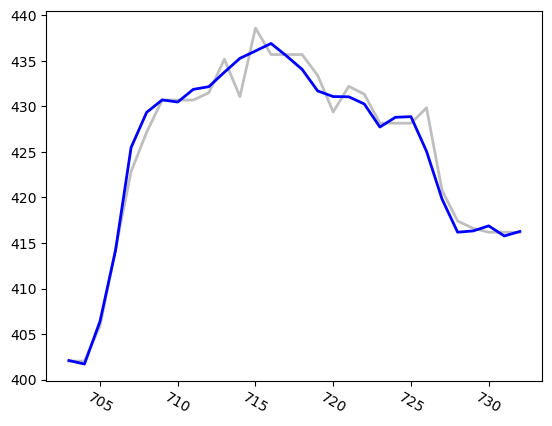

In [7]:
%matplotlib inline

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
pd.set_option('mode.chained_assignment', None)

df2=df[-30:]

df2["close_smooth"] = savgol_filter(df2.Close, 8, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

plt.show()

[13]
[]
0
0


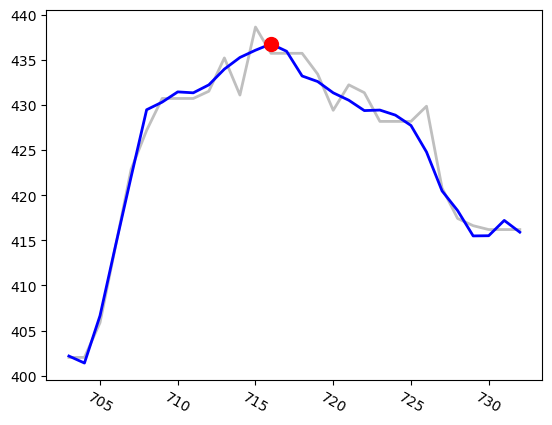

In [4]:

df2=df[-30:]

df2["close_smooth"] = savgol_filter(df2.Close, 10, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 5, width = 2, prominence=atr)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 5, width = 2, prominence=atr)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

print(peaks_idx)
print(troughs_idx)

'''
Check if we are on a up trend
'''
up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break
        
    if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
        up_run_length += 1
    else:
        up_run = False 
        
print(up_run_length)

'''
Check if we are on a down trend
'''
down_run_length = 0
down_run = True
while down_run:
    if 2 + down_run_length > len(peaks_idx) or 2 + down_run_length > len(troughs_idx):
        break
    
    if df2.close_smooth.iloc[peaks_idx[-1 - down_run_length]] < df2.close_smooth.iloc[peaks_idx[-2 - down_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - down_run_length]] < df2.close_smooth.iloc[troughs_idx[-2 - down_run_length]]:
        down_run_length += 1
    else:
        down_run = False 

if up_run_length > 0:
    ax.set_facecolor('azure')  
elif down_run_length > 0:
    ax.set_facecolor('mistyrose') 
else:
    ax.set_facecolor("white")
        
print(down_run_length)

plt.show()